# Preliminary Exercises

These exercises use `blackmarblepy` to retrieve NASA Black Marble rasters for Nigeria.

## Setup

Run these setup cells first. They load packages, find the repository root, read your NASA Earthdata bearer token, and load the Nigeria ADM0 boundary.

### Import Packages

In [1]:
import os
from pathlib import Path
from getpass import getpass

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray  # noqa: F401 - registers the .rio accessor
from dotenv import dotenv_values
from shapely.geometry import box

from blackmarble import Product, raster

### Set Project Paths

In [2]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "spatial-blackmarble-training").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "ntl_blackmarble" / "nigeria" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

### Load Black Marble Token

In [ ]:
secrets_path = REPO_ROOT / ".config" / "ntl-training" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()

### Load Nigeria Boundary

In [5]:
adm0 = gpd.read_file(DATA_DIR / "gadm" / "nga_adm0.geojson")
adm0["geometry"] = adm0.geometry.make_valid()
adm0 = adm0.to_crs("EPSG:4326")

adm0.head()

,COUNTRY,geometry
0,Nigeria,"MULTIPOLYGON (((6.43875 4.39375, 6.43904 4.393..."


### Create Download Region

In [6]:
# Download against a simple bounding box around Nigeria.
adm0_bbox = gpd.GeoDataFrame(geometry=[box(*adm0.total_bounds)], crs=adm0.crs)
adm0_bbox

,geometry
0,"POLYGON ((14.67642 4.27042, 14.67642 13.89201,..."


## Exercise 1

__Exercise: Use `raster.bm_raster` to extract a raster of the quality of NTL for January 2024 monthly data.__

* The quality variable is: `NearNadir_Composite_Snow_Free_Quality` for the monthly Product
* After extracting the data, plot it.
* What do the different quality numbers mean?

In [ ]:
# Fill in the missing variable name.
quality = raster.bm_raster(
    adm0_bbox,
    Product.VNP46A3,
    pd.date_range("2024-01-01", "2024-01-01", freq="MS"),
    token=blackmarble_token,
    output_directory=None,
    output_skip_if_exists=True,
    variable="",  # SET THIS TO SOMETHING !!!!!
)

# Plot

['h18v07', 'h18v08', 'h19v07', 'h19v08']
['h18v07', 'h18v08', 'h19v07', 'h19v08']
['https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h18v07.002.2025161151918.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h18v08.002.2025161151844.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h19v07.002.2025161151908.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h19v08.002.2025161151914.h5']


  0%|          | 0.00/65.3M [00:00<?, ?B/s]

  0%|          | 0.00/72.8M [00:00<?, ?B/s]

  0%|          | 0.00/64.1M [00:00<?, ?B/s]

  0%|          | 0.00/65.2M [00:00<?, ?B/s]

COLLATING TILES | Processing...:   0%|          | 0/1 [00:00<?, ?date/s]

### Solution

['h18v07', 'h18v08', 'h19v07', 'h19v08']
['h18v07', 'h18v08', 'h19v07', 'h19v08']
['https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h18v07.002.2025161151918.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h18v08.002.2025161151844.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h19v07.002.2025161151908.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h19v08.002.2025161151914.h5']


  0%|          | 0.00/65.3M [00:00<?, ?B/s]

  0%|          | 0.00/72.8M [00:00<?, ?B/s]

  0%|          | 0.00/64.1M [00:00<?, ?B/s]

  0%|          | 0.00/65.2M [00:00<?, ?B/s]

COLLATING TILES | Processing...:   0%|          | 0/1 [00:00<?, ?date/s]

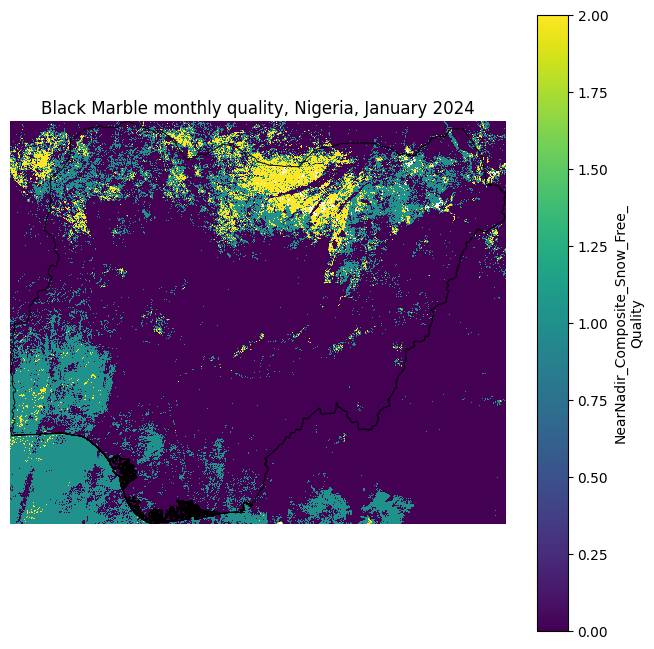

In [25]:
quality = raster.bm_raster(
    adm0_bbox,
    Product.VNP46A3,
    pd.date_range("2024-01-01", "2024-01-01", freq="MS"),
    token=blackmarble_token,
    output_directory=None,
    output_skip_if_exists=True,
    variable="NearNadir_Composite_Snow_Free_Quality",
)

quality_da = quality["NearNadir_Composite_Snow_Free_Quality"].squeeze()

fig, ax = plt.subplots(figsize=(8, 8))
quality_da.plot(ax=ax, cmap="viridis", add_colorbar=True)
adm0.boundary.plot(ax=ax, color="black", linewidth=0.7)
ax.set_title("Black Marble monthly quality, Nigeria, January 2024")
ax.set_axis_off()
plt.show()

**What are your findings from this image? Is the quality good or not good enough? Why?**

## Exercise 2

__Exercise: Use `raster.bm_raster` to extract a raster of NTL for 2022, 2023, and 2024. Create a plot that shows the log of average nighttime lights across those three years at the pixel level.__

In [ ]:
# Fill in the missing product and dates.
ntl = raster.bm_raster(
    adm0_bbox,
    None,  # CHANGE TO SOMETHING !!!!!
    None,  # CHANGE TO SOMETHING !!!!!
    token=blackmarble_token,
    output_directory=str(RAW_DIR),
    output_skip_if_exists=True,
)

# Make average and log

# Plot

### Solution

['h18v07', 'h18v08', 'h19v07', 'h19v08']
['h18v07', 'h18v08', 'h19v07', 'h19v08']
['https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h18v07.002.2025161113010.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2022001.h18v07.002.2025156103531.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2024001.h18v07.002.2025162031135.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2022001.h18v08.002.2025156103341.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h18v08.002.2025161113203.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2024001.h18v08.002.2025162031854.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2022001.h19v07.002.2025156103357.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h19v07.002.2025161112717.h5', 'https://ladsweb.modaps.eosdi

  0%|          | 0.00/72.4M [00:00<?, ?B/s]

  0%|          | 0.00/72.8M [00:00<?, ?B/s]

  0%|          | 0.00/73.7M [00:00<?, ?B/s]

  0%|          | 0.00/83.9M [00:00<?, ?B/s]

...

  0%|          | 0.00/73.9M [00:00<?, ?B/s]

  0%|          | 0.00/78.2M [00:00<?, ?B/s]

  0%|          | 0.00/77.5M [00:00<?, ?B/s]

  0%|          | 0.00/80.1M [00:00<?, ?B/s]

COLLATING TILES | Processing...:   0%|          | 0/3 [00:00<?, ?date/s]

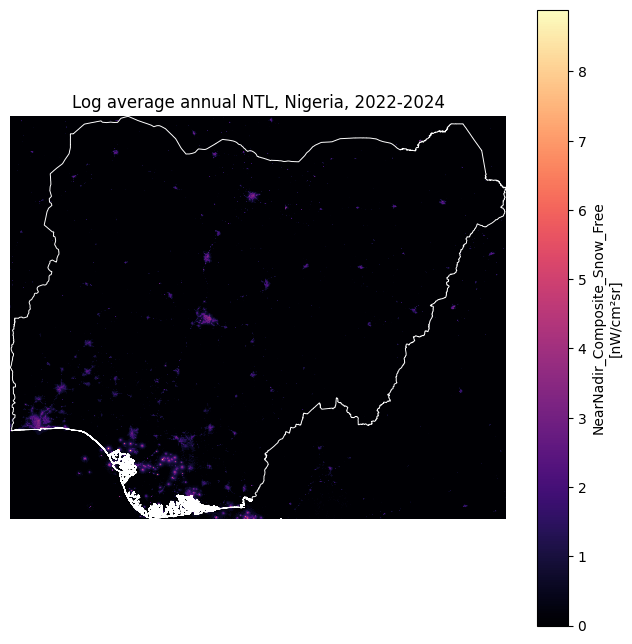

In [ ]:
ntl = raster.bm_raster(
    adm0_bbox,
    Product.VNP46A4,
    pd.date_range("2022-01-01", "2024-01-01", freq="YS"),
    token=blackmarble_token,
    output_directory=None,
    output_skip_if_exists=True,
)

## Optional if you want to save the rasters
ntl = ntl.rio.write_crs("EPSG:4326")

for t in ntl.time.values:
    date_str = str(t)[:7]  # e.g. "2022-01"
    ntl["NearNadir_Composite_Snow_Free"].sel(time=t).rio.to_raster(f"../../data/ntl_blackmarble/nigeria/ntl_{date_str}.tif")
########

ntl_da = ntl["NearNadir_Composite_Snow_Free"]
ntl_avg = ntl_da.mean(dim="time", skipna=True)
ntl_avg_log = np.log1p(ntl_avg)

fig, ax = plt.subplots(figsize=(8, 8))
ntl_avg_log.plot(ax=ax, cmap="magma", add_colorbar=True)
adm0.boundary.plot(ax=ax, color="white", linewidth=0.7)
ax.set_title("Log average annual NTL, Nigeria, 2022-2024")
ax.set_axis_off()
plt.show()